# 03 – Improvements: Group Features and an Ensemble

> **Project notebooks:** [01 Exploration](01_exploration.ipynb) · [02 Modelling](02_modelling.ipynb) · [03 Improvements](03_improvements.ipynb) · [04 Pipelines](04_pipelines.ipynb) · [05 Saving & explaining](05_saving_and_explaining.ipynb)

Our first Kaggle score (0.775, from [02_modelling](02_modelling.ipynb)) was about 6 points below the cross‑validated accuracy, so there is room to improve.

**In this notebook we:**
1. Set up the data and the tuned models from notebook 02.
2. Add **new features**: the cabin **deck**, the **ticket group size** and **fare per person**.
3. Add a **group survival** feature: passengers who travelled together (same ticket or same family) often survived or died together.
4. Check whether the new features help.
5. **Combine several models** in a voting ensemble.
6. Create a second Kaggle submission.

## 1. Setup

We load the raw data and recreate what we need from notebook 02:
- the statistics used for cleaning (learned from the **training** data only),
- the cross‑validation folds,
- the **tuned models**. Instead of running the slow searches again, we write down the best settings that notebook 02 found. This is common in real projects: search once, then record the result.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/train.csv")
test_raw = pd.read_csv("../data/test.csv")
submission = pd.read_csv("../submissions/submission.csv")  # first submission, from notebook 02
y = df["Survived"]

# Cleaning statistics, learned from the training data only
titles = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
rare = titles.value_counts()[lambda s: s < 10].index
titles = titles.replace(rare, "Rare")
common_titles = titles.unique()
title_age_median = df.groupby(titles)["Age"].median()
class_fare_median = df.groupby("Pclass")["Fare"].median()
embarked_mode = df["Embarked"].mode()[0]

features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "HasCabin", "Embarked", "Title"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Best settings found by the searches in notebook 02
rf_tuned = RandomForestClassifier(n_estimators=500, max_depth=4, min_samples_leaf=2,
                                  max_features="sqrt", random_state=42)
gb_tuned = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=4,
                                      subsample=0.8, random_state=42)
xgb_tuned = XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=2, subsample=0.7,
                          colsample_bytree=0.6, min_child_weight=1,
                          eval_metric="logloss", random_state=42)

print(f"Training passengers: {len(df)}, test passengers: {len(test_raw)}")

Training passengers: 891, test passengers: 418


## 2. New features from `Cabin`, `Ticket` and `Name`

- **Deck**: the first letter of the cabin (A = top deck … F = lower decks). `U` = unknown. The rare decks G and T are merged into `U`.
- **TicketGroupSize**: how many passengers share the same ticket number. Friends, servants and nannies often shared a ticket without being family, so this captures groups that `FamilySize` misses.
- **FarePerPerson**: the `Fare` is the price of the whole ticket, so we divide it by the group size.

We count tickets across **train and test together**. This only uses passenger information, never the `Survived` labels, so it is allowed: a group may have members in both files.

In [2]:
full = pd.concat([df, test_raw], ignore_index=True)
n_train = len(df)

# Same cleaning as before (statistics from training data only)
full["Title"] = full["Name"].str.extract(r",\s*([^\.]+)\.")
full["Title"] = full["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
full.loc[~full["Title"].isin(common_titles), "Title"] = "Rare"
full["Age"] = full["Age"].fillna(full["Title"].map(title_age_median))
full["Fare"] = full["Fare"].fillna(full["Pclass"].map(class_fare_median))
full["Embarked"] = full["Embarked"].fillna(embarked_mode)
full["HasCabin"] = full["Cabin"].notna().astype(int)
full["FamilySize"] = full["SibSp"] + full["Parch"] + 1

# New features
full["Deck"] = full["Cabin"].str[0].fillna("U").replace({"G": "U", "T": "U"})
full["TicketGroupSize"] = full.groupby("Ticket")["Ticket"].transform("size")
full["FarePerPerson"] = full["Fare"] / full["TicketGroupSize"]

full[["Name", "Cabin", "Deck", "Ticket", "TicketGroupSize", "Fare", "FarePerPerson"]].head()

,Name,Cabin,Deck,Ticket,TicketGroupSize,Fare,FarePerPerson
0,"Braund, Mr. Owen Harris",NaN,U,A/5 21171,1,7.2500,7.25000
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",C85,C,PC 17599,2,71.2833,35.64165
2,"Heikkinen, Miss. Laina",NaN,U,STON/O2. 3101282,1,7.9250,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",C123,C,113803,2,53.1000,26.55000
4,"Allen, Mr. William Henry",NaN,U,373450,1,8.0500,8.05000


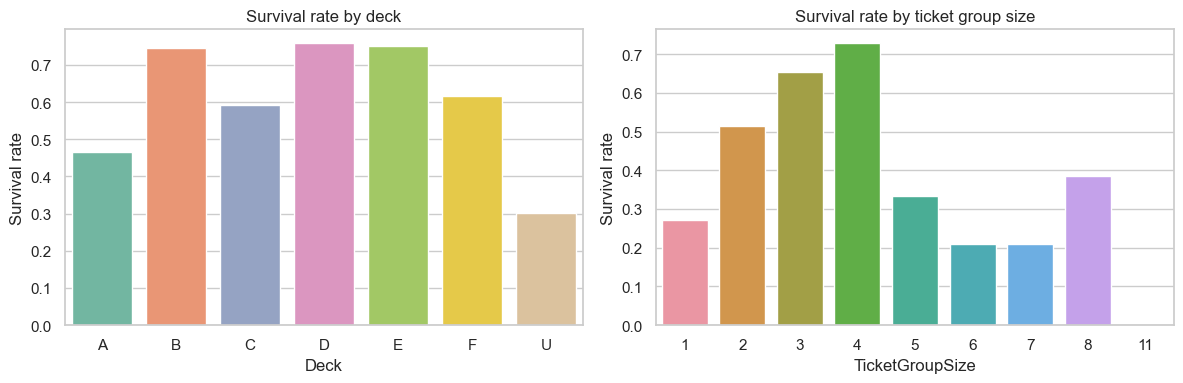

In [3]:
train_full = full.iloc[:n_train]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=train_full, x="Deck", y="Survived", order=sorted(train_full["Deck"].unique()),
            ax=axes[0], errorbar=None)
axes[0].set(title="Survival rate by deck", ylabel="Survival rate")
sns.barplot(data=train_full, x="TicketGroupSize", y="Survived", ax=axes[1], errorbar=None)
axes[1].set(title="Survival rate by ticket group size", ylabel="Survival rate")
plt.tight_layout()
plt.show()

Passengers with a known deck (mostly 1st class) survived far more often than those with an unknown cabin (`U`).
The ticket group pattern looks like family size: groups of 2–4 did best.

## 3. Group survival

If we know what happened to the **other members** of a passenger's group, that is a strong hint about what happened to them.
For example, in a family where the mother and children all died, a remaining child very likely died too.

We define two kinds of group:
- **Family**: same surname, same class and same fare (to avoid joining unrelated people with common surnames like "Smith").
- **Ticket**: same ticket number.

For every passenger, `GroupSurvival` is the survival rate of the **other** group members whose outcome we know (from `train.csv`).
A passenger's own label is **never** used for their own feature.
If there is no known group member, we use 0.5 ("no information") and set `GroupKnown` = 0.

In [4]:
full["Surname"] = full["Name"].str.split(",").str[0]
full["FamilyGroup"] = full["Surname"] + "_" + full["Pclass"].astype(str) + "_" + full["Fare"].round(1).astype(str)


def others_survival_rate(group_col):
    """Survival rate of the *other* known members of each passenger's group (NaN if none)."""
    known = full["Survived"]                      # NaN for test passengers
    group_sum = full.groupby(group_col)["Survived"].transform("sum")
    group_count = full.groupby(group_col)["Survived"].transform("count")
    others_sum = group_sum - known.fillna(0)      # remove the passenger's own label
    others_count = group_count - known.notna()
    return (others_sum / others_count).where(others_count > 0)


family_rate = others_survival_rate("FamilyGroup")
ticket_rate = others_survival_rate("Ticket")

full["GroupSurvival"] = family_rate.fillna(ticket_rate).fillna(0.5)
full["GroupKnown"] = (family_rate.notna() | ticket_rate.notna()).astype(int)

print(f"Training passengers with a known group member: {full['GroupKnown'][:n_train].mean():.0%}")
print(f"Test passengers with a known group member:     {full['GroupKnown'][n_train:].mean():.0%}")

Training passengers with a known group member: 43%
Test passengers with a known group member:     42%


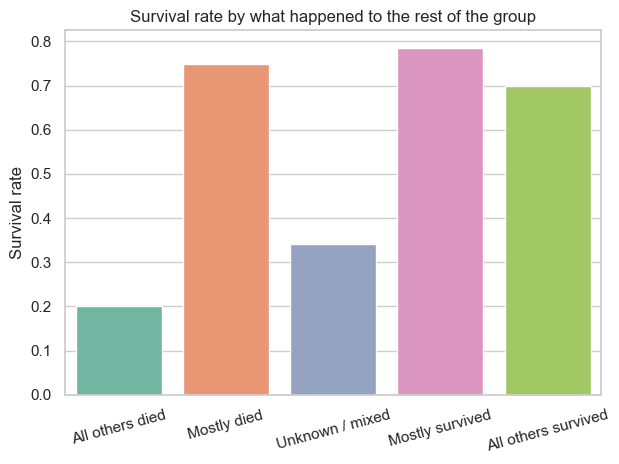

In [5]:
train_full = full.iloc[:n_train]
group_view = train_full.assign(
    Group=pd.cut(train_full["GroupSurvival"], bins=[-0.01, 0.0, 0.49, 0.5, 0.99, 1.0],
                 labels=["All others died", "Mostly died", "Unknown / mixed", "Mostly survived", "All others survived"]).astype(str)
)
ax = sns.barplot(data=group_view, x="Group", y="Survived", errorbar=None,
                 order=["All others died", "Mostly died", "Unknown / mixed", "Mostly survived", "All others survived"])
ax.set(title="Survival rate by what happened to the rest of the group", xlabel="", ylabel="Survival rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../images/group_survival.png", dpi=120)
plt.show()

This is a very strong signal: when all other known group members died, very few passengers survived, and when all others survived, most did.

## 4. Do the new features help?

We compare three feature sets with the tuned Gradient Boosting model, using the same cross‑validation folds as notebook 02.
This time we evaluate on **all 891** training passengers, because the final model is trained on all of them.

> **Note:** `GroupSurvival` for a passenger is built from the labels of *other* passengers. Inside cross‑validation some of those other passengers sit in the validation fold, so the CV score here is a little optimistic. The Kaggle score is the real test.

In [6]:
cat_cols = ["Sex", "Embarked", "Title", "Deck"]
feature_sets = {
    "Original features": features,
    "+ deck & ticket": features + ["Deck", "TicketGroupSize", "FarePerPerson"],
    "+ deck, ticket & group survival": features + ["Deck", "TicketGroupSize", "FarePerPerson", "GroupSurvival", "GroupKnown"],
}


def encode(cols):
    encoded = pd.get_dummies(full[cols], columns=[c for c in cat_cols if c in cols], drop_first=True)
    return encoded.iloc[:n_train], encoded.iloc[n_train:]


rows = []
for name, cols in feature_sets.items():
    X_tr, _ = encode(cols)
    scores = cross_val_score(gb_tuned, X_tr, y, cv=cv, scoring="accuracy")
    rows.append({"feature set": name, "CV accuracy": scores.mean(), "CV std": scores.std()})

pd.DataFrame(rows).set_index("feature set").round(3)

,CV accuracy,CV std
feature set,,
Original features,0.845,0.015
+ deck & ticket,0.848,0.015
"+ deck, ticket & group survival",0.855,0.009


The deck and ticket features give a small gain; the group survival feature gives the biggest jump.

## 5. Voting ensemble

Different models make different mistakes. A **soft‑voting ensemble** averages the predicted survival probabilities of several models, which often makes the predictions more stable.
We combine the four tuned models from notebook 02.

In [7]:
from sklearn.ensemble import VotingClassifier

X_new, X_submit_new = encode(feature_sets["+ deck, ticket & group survival"])

ensemble = VotingClassifier(
    estimators=[
        ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
        ("rf", clone(rf_tuned)),
        ("gb", clone(gb_tuned)),
        ("xgb", clone(xgb_tuned)),
    ],
    voting="soft",
)

new_models = {
    "Logistic Regression": ensemble.named_estimators["lr"],
    "Random Forest (tuned)": ensemble.named_estimators["rf"],
    "Gradient Boosting (tuned)": ensemble.named_estimators["gb"],
    "XGBoost (tuned)": ensemble.named_estimators["xgb"],
    "Voting ensemble": ensemble,
}

rows = []
for name, model in new_models.items():
    scores = cross_val_score(model, X_new, y, cv=cv, scoring="accuracy")
    rows.append({"model": name, "CV accuracy": scores.mean(), "CV std": scores.std()})

results_new = pd.DataFrame(rows).set_index("model").sort_values("CV accuracy", ascending=False)
results_new.round(3)

,CV accuracy,CV std
model,,
Gradient Boosting (tuned),0.855,0.009
Voting ensemble,0.852,0.012
XGBoost (tuned),0.851,0.012
Random Forest (tuned),0.845,0.009
Logistic Regression,0.837,0.017


With the new features, every model improves compared with notebook 02. The ensemble scores almost the same as the best single model (Gradient Boosting); the difference is far smaller than the spread between folds, so on this data the two are effectively tied.
We submit the **ensemble** for the second submission because our first submission already used Gradient Boosting alone. This way Kaggle tells us whether combining models helps on unseen passengers.

## 6. Second Kaggle submission

In [8]:
final_ensemble = clone(ensemble).fit(X_new, y)

submission_v2 = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": final_ensemble.predict(X_submit_new).astype(int),
})
submission_v2.to_csv("../submissions/submission_v2_groups_ensemble.csv", index=False)

changed = (submission_v2["Survived"] != submission["Survived"]).sum()
print(f"Saved {len(submission_v2)} predictions to submissions/submission_v2_groups_ensemble.csv")
print(f"Predicted survival rate: {submission_v2['Survived'].mean():.1%}")
print(f"Predictions changed compared with the first submission: {changed} of {len(submission_v2)}")

Saved 418 predictions to submissions/submission_v2_groups_ensemble.csv
Predicted survival rate: 36.1%
Predictions changed compared with the first submission: 37 of 418


Upload `submissions/submission_v2_groups_ensemble.csv` on the [competition page](https://www.kaggle.com/competitions/titanic/submissions) the same way as before.

| Submission | Model | Kaggle public score |
|---|---|---|
| v1 | Gradient Boosting (tuned), original features | 0.77511 |
| v2 | Voting ensemble, + deck, ticket & group survival | **0.79186** |

The group features and the ensemble improved the leaderboard score by **1.7 percentage points** (0.775 → 0.792), roughly 7 more correct passengers out of 418. The gap between cross‑validation and Kaggle stayed at about 6 points, so the model still fits the small training set more closely than unseen data.

## 7. Conclusions

- **What happened to your travel group** was one of the strongest predictors of survival, after sex and class. Families and ticket groups tended to survive or die together.
- **The Kaggle score improved from 0.775 to 0.792** with the group features and the ensemble.
- **Deck, ticket group size and fare per person** added a little extra signal.
- **The ensemble** performed about as well as the best single model in cross‑validation; on a dataset this small, combining models gives little extra.
- **Lesson learned:** on small tabular datasets, understanding the data and building good features matters more than choosing a fancier algorithm.

**Next:** in [04_pipelines](04_pipelines.ipynb) we rebuild the cleaning and the model as one scikit‑learn `Pipeline`, the way it is done in real projects.